In [1]:
# For google colab
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/Othercomputers/My Mac/DeepElig/KP/src/')
colab=True
!python '/content/drive/Othercomputers/My Mac/DeepElig/KP/src/SpeechPreprocess.py'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from pathlib import Path
from tqdm import tqdm
import IPython.display as ipd
import json
import sys
import os
if 'colab' not in locals():
  sys.path.insert(0, "../src/")
from Network import *
from plotting import *
from utilsSpeech import *
from utils import *

import torchaudio
from torch.utils.data import DataLoader

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)
model_config = dict(default_model_config)
dt = general_config["dt"]

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

cpu


## Prepare dataloader

Shape of waveform: torch.Size([1, 16000])
Sample rate of waveform: 16000


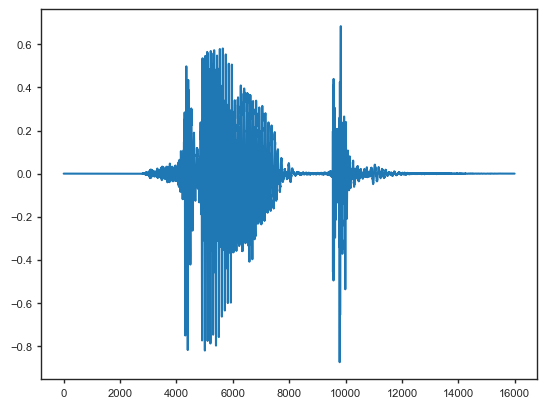

In [3]:
# Create training and testing split of the data. We do not use validation in this tutorial.
val_set = SubsetSC("validation")

waveform, sample_rate, label, speaker_id, utterance_number = val_set[238]
data_config['sample_rate'] = sample_rate

print("Shape of waveform: {}".format(waveform.size()))
print("Sample rate of waveform: {}".format(sample_rate))

plt.plot(waveform.t().numpy());

In [4]:
import IPython.display as ipd
print(label)
ipd.Audio(waveform.numpy(), rate=sample_rate)

right


In [5]:
data_config["task"] = "Cmd20"
if data_config["task"]=="Cmd20":
    data_config["n_class"] = len(COMMAND20)
elif data_config["task"]=="Full":
    data_config["n_class"] = len(LABELS)
data_config["n_steps"] = int(data_config["duration"]/dt)

n_class = data_config["n_class"]
n_steps = data_config["n_steps"]
answer_steps = int(model_config["answer_period"]/dt)
rootdir = Path('..') / "SpeechCommands" / "Mel_npy"

train_set = ShardedMelDataset(rootdir / 'training', task=data_config["task"])
val_set = ShardedMelDataset(rootdir / 'validation', task=data_config["task"])

mel_sample, label = val_set[0]
print(mel_sample.shape)
data_config['n_mels'] = mel_sample.shape[0]

if device == "cuda":
    num_workers = 0 #train_config['num_workers']
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

if train_config["weighted_sampler"]:
    with open(rootdir / "training"/ "label_stats.json") as f:
        label_counts = json.load(f)["label_counts"]
    sampler = make_weighted_sampler(train_set, label_counts)
    shuffle = False
else:
    sampler = None
    shuffle = True

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=128, #train_config['batch_size'],
    shuffle=shuffle,
    sampler=sampler,
    collate_fn=CollateMel(n_steps, n_class, training=True),
    num_workers=1,
    pin_memory=pin_memory,
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    collate_fn=CollateMel(n_steps, n_class, training=False),
    num_workers=num_workers,
    pin_memory=pin_memory,
)

train_config["batches_per_epoch"] = len(train_loader)

model_config['n_out'] = data_config['n_class']
model_config['n_in'] = data_config['n_mels']
answer_steps=250
beta = torch.zeros(n_steps).to(device)
beta[-answer_steps:]=1.
beta /= beta.sum()

torch.Size([64, 200])


torch.Size([2, 64, 500]) torch.Size([2, 20])


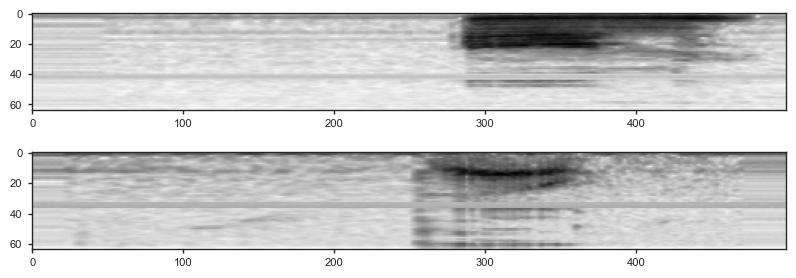

In [7]:
example_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=2,
    shuffle=True,
    collate_fn=CollateMel(n_steps, n_class, training=True, mask_width=0),
    num_workers=1,
    pin_memory=False,
)
mel_sample, label = next(iter(example_loader))
print(mel_sample.shape, label.shape)
del example_loader

fig, axs = plt.subplots(2, 1, figsize=(8, 3))
axs[0].imshow(mel_sample[0].numpy())
axs[1].imshow(mel_sample[1].numpy())
plt.tight_layout()
plt.show()

## Training KP

In [7]:
# init network and optimizer
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.4,
    patience=0
)

best_val_acc = 0.

tensor([ 4., 16., 48.,  3., 12., 24.])


In [8]:
print("Training started...")
loss_record = []
for epoch in range(2): #One epoch for demo
    Cum_errors=0.
    pbar = tqdm(
        enumerate(train_loader, 0),
        total=train_config["batches_per_epoch"],
        disable=not general_config["verbose"],
    )
    for batch_idx, (x, target) in pbar:
        if train_config["error_steps"]==-1: #All steps in answering period
            beta_temp = beta
        else: #Random selected steps in answering period
            beta_temp = torch.zeros(n_steps).to(device)
            select_steps = np.random.choice(answer_steps, train_config["error_steps"], replace=False)
            beta_temp[select_steps+n_steps-answer_steps] = 1.
            beta_temp /= beta_temp.sum()
        total_error = train_batch_delay(model, optimizer, x.to(device),
                                        target.to(device), answer_steps, beta_temp)
        Cum_errors += total_error

    Cum_errors /= len(train_loader.dataset)

    val_acc, val_loss = test(model, val_loader, answer_steps, beta)
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {val_loss:.4f},'
        f'Test Acc: {val_acc:.1f},'
        f'Best Acc: {best_val_acc:.1f},'
    )
    pbar.close()

print('finished')

Training started...


  1%|▋                                                                                  | 4/484 [00:18<36:52,  4.61s/it]


KeyboardInterrupt: 

### Visualize kernel

In [ ]:
kernel_record_post = extract_kernel(
    model,
    n_steps=int(1.5*data_config["final_seq_length"]),
    layer_idx=model_config["num_LP_layers"]
)

In [ ]:
kernel_record_pre_norm = kernel_record_pre / kernel_record_pre.mean(axis=1)[:, None]
kernel_record_post_norm = kernel_record_post / kernel_record_post.mean(axis=1)[:, None]
fig, axs = plt.subplots(10, 6, figsize=(16, 14))
for i, ax in enumerate(axs.ravel()):
    ax.plot(kernel_record_pre_norm[i])
    ax.plot(kernel_record_post_norm[i])

In [ ]:
# if data_config['preprocessing']=='Mel':
#     transform = torchaudio.transforms.MelSpectrogram(
#         sample_rate=data_config['sample_rate'],
#         n_fft=data_config['n_fft'],
#         win_length=data_config['win_length'],
#         hop_length=data_config['hop_length'],
#         n_mels=data_config['n_mels'],
#         center=True
#     )
# elif data_config['preprocessing']=='Raw':
#     new_sample_rate = 10000
#     transform = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)

# transformed = transform(waveform)[:, :, :-1]

# data_config["final_seq_length"] = transformed.shape[-1]
# data_config["n_class"] = len(LABELS)
# n_class = data_config["n_class"]
# n_steps = data_config["final_seq_length"]
# answer_steps = int(model_config["answer_period"]/dt)

# word_start = "yes"
# index = label_to_index(word_start)
# word_recovered = index_to_label(index)

# print(word_start, "-->", index, "-->", word_recovered,
#       ", transformed shape:", transformed.shape, ", Number of steps:", n_steps)

yes --> tensor(33) --> yes , transformed shape: torch.Size([1, 64, 500]) , Number of steps: 500


## Evaluation

In [19]:
rootdir = Path('..') / "SpeechCommands" / "Mel_80"
Saved_model = Path("..") / "saved_models" / "Cmd20BPTT93.3"
with open(Saved_model / "general_config.json") as f:
    general_config = json.load(f)
with open(Saved_model / "model_config.json") as f:
    model_config = json.load(f)
with open(Saved_model / "data_config.json") as f:
    data_config = json.load(f)

dt = general_config["dt"]
n_steps = int(data_config["duration"]/dt)
answer_steps = int(model_config["answer_period"]/dt)

if device == "cuda":
    num_workers = 1
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

collate_fn = CollateMel(n_steps, data_config['n_class'])

test_set = ShardedMelDataset(rootdir / 'testing')
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

train_set = ShardedMelDataset(rootdir / 'training')
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

In [20]:
model = buildNetCompare(model_config, general_config, neurontype="BPTT").to(device)
model = torch.compile(model)
state_dict = torch.load(Saved_model / "best_model_state.pt", map_location=device, weights_only=True)
print(model.load_state_dict(state_dict))
print(model_config)

beta = torch.zeros(n_steps).to(device)
beta[-answer_steps:]=1.
beta /= beta.sum()

model.device = device
for l in model.layers:
    l.device = device

<All keys matched successfully>
{'Ins_size': [360], 'LP_size': [240, 300, 300, 300, 360], 'Tau0': [2, 40, 6], 'Tau1': [3, 12, 24], 'Tau2': [4, 16, 36], 'Tau3': [5.0, 14.0], 'Tau4': [200.0, 1000.0], 'activation': 'tanh', 'answer_period': 500, 'n_in': 80, 'n_out': 20, 'num_Ins_layers': 1, 'num_LP_layers': 5, 'reducedNonlinear': False, 'rho_scale': 0.6}


In [98]:
beta = torch.zeros(n_steps).to(device)
answer_steps = 250
beta[-answer_steps:]=torch.logspace(0, 1, answer_steps)
beta /= beta.sum()

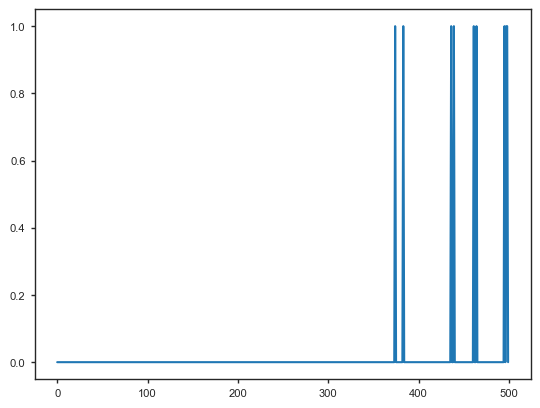

In [99]:
p = np.logspace(0, 1, answer_steps)
p /= p.sum()
error_steps = np.random.choice(answer_steps, 10, p=p)
beta = torch.zeros(n_steps).to(device)
beta[error_steps+n_steps-answer_steps] = 1
plt.plot(beta)

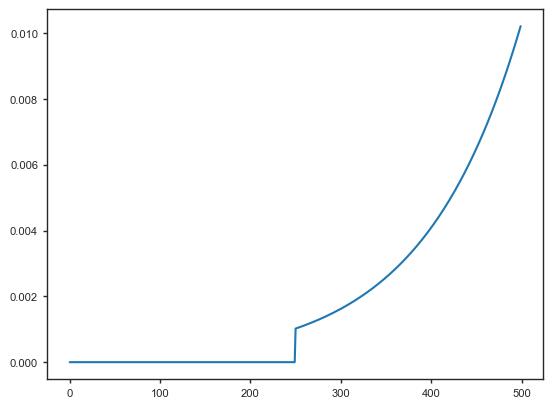

In [84]:
plt.plot(beta)

In [80]:
test_acc, test_loss, test_stats = test_analy_confusion(model, test_loader, answer_steps, beta, num_classes=data_config['n_class'])

Accuracy: 93.65603226989366
Loss: 0.0120426547977572
False Positive per class:  [19 22 23 16 19 31 13 21 22 21 14 60 27 29 22 17 27 45 23 48]
Precision per class:  [0.9543269  0.9447236  0.9451074  0.96009976 0.9525     0.9309577
 0.9675     0.9489051  0.94554454 0.94840294 0.9669031  0.85882354
 0.9338235  0.9282178  0.94749403 0.95607233 0.9298701  0.8897059
 0.9452381  0.87909317]
False Negative per class:  [21 23 28 20 19 27  7 16 26 22 10 40 44 31 15 26 38 39 14 53]
Recall per class: [0.9497608  0.9423559  0.9339623  0.9506173  0.9525     0.93932587
 0.9822335  0.96059114 0.9362745  0.9460784  0.97613364 0.90123457
 0.8964706  0.9236453  0.96359223 0.93434346 0.9040404  0.9029851
 0.9659367  0.8681592 ]


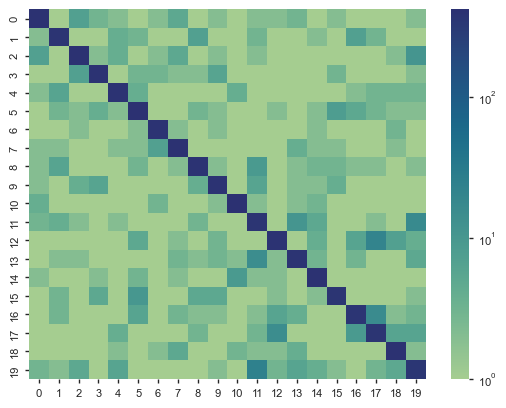

In [81]:
import seaborn as sn
from matplotlib.colors import LogNorm
print("Accuracy:", test_acc)
print("Loss:", test_loss)
print("False Positive per class: ", test_stats["FP"])
print("Precision per class: ", test_stats["precision"])
print("False Negative per class: ", test_stats["FN"])
print("Recall per class:", test_stats["recall"])
sn.heatmap(test_stats["confusion_matrix"]+1, annot=False, norm=LogNorm(), cmap="crest")
#plt.imshow(stats["confusion_matrix"])
plt.show()

In [28]:
test_stats["Mistakes"]

array([   2,   28,   30,   31,   37,   42,   49,   50,   93,  103,  109,
        120,  121,  164,  184,  186,  199,  205,  212,  213,  247,  250,
        251,  252,  253,  254,  255,  283,  307,  309,  356,  378,  380,
        482,  498,  545,  582,  583,  585,  586,  588,  589,  590,  591,
        592,  594,  599,  616,  619,  680,  710,  727,  728,  776,  788,
        815,  852,  854,  855,  865,  866,  881,  882,  913,  921,  925,
        966,  992,  997, 1039, 1064, 1069, 1070, 1075, 1094, 1107, 1125,
       1128, 1188, 1191, 1207, 1210, 1232, 1233, 1238, 1305, 1306, 1312,
       1318, 1319, 1353, 1354, 1355, 1393, 1394, 1396, 1439, 1465, 1466,
       1502, 1568, 1612, 1632, 1633, 1647, 1661, 1663, 1664, 1670, 1694,
       1698, 1704, 1707, 1714, 1716, 1754, 1757, 1768, 1807, 1811, 1812,
       1815, 1816, 1817, 1826, 1838, 1839, 1841, 1842, 1843, 1844, 1845,
       1846, 1847, 1848, 1850, 1851, 1854, 1876, 1879, 1881, 1895, 1897,
       1898, 1923, 1938, 1954, 1974, 1985, 1987, 20

In [30]:
#test_set_full = ShardedMelDataset(rootdir / 'testing', task="Full")
wrong = np.zeros(35)
for i in test_stats["Mistakes"]:
    _, label = test_set[i]
    wrong[label]+=1

wrong_dic = {}
for i in range(35):
    wrong_dic[LABELS[i]] = int(wrong[i])
print(wrong_dic)

{'backward': 14, 'bed': 17, 'bird': 5, 'cat': 17, 'dog': 14, 'down': 26, 'eight': 25, 'five': 41, 'follow': 13, 'forward': 10, 'four': 28, 'go': 48, 'happy': 17, 'house': 21, 'learn': 18, 'left': 39, 'marvin': 8, 'nine': 28, 'no': 15, 'off': 9, 'on': 16, 'one': 16, 'right': 31, 'seven': 40, 'sheila': 11, 'six': 11, 'stop': 18, 'three': 0, 'tree': 0, 'two': 0, 'up': 0, 'visual': 0, 'wow': 0, 'yes': 0, 'zero': 0}


In [33]:
def test_single(model, data, answer_step, beta):
    model.eval()
    device = model.device
    mel, label = data
    x_test = F.interpolate(
        mel.unsqueeze(0),
        size=500,
        mode="linear",
        align_corners=False
    )
    with torch.no_grad():
        x_test = x_test.to(device)
        n_steps = x_test.shape[-1]
        r_out_rec = torch.zeros(n_steps, 20).to(device)
        p_rec = torch.zeros(n_steps, 20).to(device)

        model.reset()
        pred_p = 0
        for t in range(n_steps):
            r_out,_ = model.step(x_test[:,:,t])
            r_out_rec[t] = r_out
            if n_steps-t <= answer_step:
                p = torch.softmax(r_out, dim=1)
                pred_p = p*beta[t] + pred_p
                p_rec[t] = p
        prediction = torch.argmax(pred_p, dim=1)

    return p_rec, r_out_rec, label, prediction

True label:  one Classified as:  five


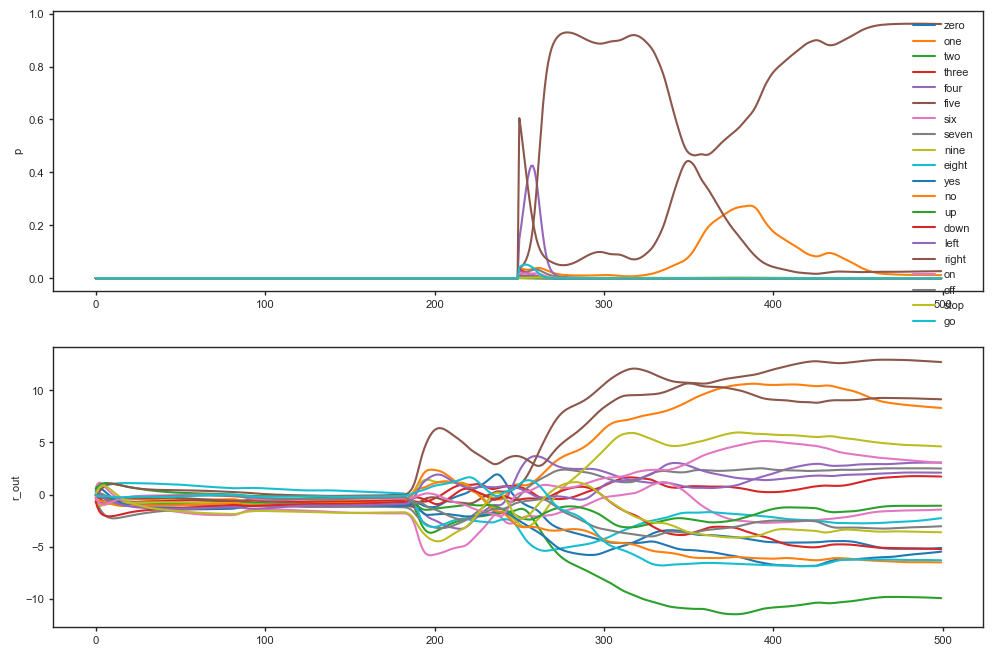

In [57]:
data_index = test_stats["Mistakes"][350] #200, 300
p_rec, r_out_rec, true_label, prediction = test_single(model, test_set[data_index], answer_steps, beta)
print("True label: ", COMMAND20[true_label], "Classified as: ", COMMAND20[prediction])
fig, axs = plt.subplots(2, 1, figsize = (12, 8))
for i, label in enumerate(COMMAND20):
    axs[0].plot(p_rec[:, i], label=label)
    axs[1].plot(r_out_rec[:, i], label=label)
axs[0].legend()
axs[0].set_ylabel("p")
axs[1].set_ylabel("r_out")
plt.show()

In [58]:
import pandas as pd

df = pd.read_csv(rootdir / "testing"/"metadata.csv")
original_index = test_set.keep_indices[0][data_index]
label = df["label_idx"][original_index]
waveform, sample_rate = torchaudio.load(df["wav_path"][original_index])
print(LABELS[label])
ipd.Audio(waveform.numpy(), rate=sample_rate)

one


## Train BPTT

In [8]:
Method = 'BPTT'
train_fn = train_batch_BPTT

model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)
model = torch.compile(model)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    weight_decay=0.
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=0
)

best_val_acc = 0.

In [9]:
num_epochs = 100
error_record = []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    pbar = tqdm(
        enumerate(train_loader, 0),
        total=train_config["batches_per_epoch"],
        disable=not general_config["verbose"],
    )
    for batch_idx, (x, target) in pbar:
        total_error = train_fn(model, optimizer, x.to(device),
                                        target.to(device), answer_steps, beta)
        Cum_errors += total_error

    Cum_errors /= len(train_loader.dataset)
    val_acc, val_loss = test(model, val_loader, answer_steps, beta)
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {val_loss:.4f},'
        f'Test Acc: {val_acc:.1f},'
        f'Best Acc: {best_val_acc:.1f},'
    )
    pbar.close()

print('finished')

  5%|████                                                                             | 33/663 [00:31<10:10,  1.03it/s]


KeyboardInterrupt: 

## Check GLE

In [7]:
Method = 'GLE'
model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-3,#train_config["learning_rate"],
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

train_fn = train_batch_delay

best_val_acc = 0.

In [8]:
print("Training started...")
loss_record = []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    pbar = tqdm(
        enumerate(train_loader, 0),
        total=train_config["batches_per_epoch"],
        disable=not general_config["verbose"],
    )
    for batch_idx, (x, target) in pbar:
        total_error = train_batch_delay(model, optimizer, x.to(device),
                                        target.to(device), answer_steps, beta)
        Cum_errors += total_error

    Cum_errors /= len(train_loader.dataset)

    val_acc, val_loss = test(model, val_loader, answer_steps, beta)
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {val_loss:.4f},'
        f'Test Acc: {val_acc:.1f},'
        f'Best Acc: {best_val_acc:.1f},'
    )
    pbar.close()

print('finished')

Training started...


  2%|█▌                                                                           | 13/663 [00:12<10:06,  1.07it/s]


KeyboardInterrupt: 